In [33]:
import os
RANDOM_STATE = 42
N_JOBS = int(os.cpu_count() * 1)

In [34]:
from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(subset='SA', percent10=True, random_state=RANDOM_STATE)


In [35]:
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y_raw = pd.Series(data.target)

cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in X_raw.columns if c not in cat_cols]

for c in cat_cols:
    X_raw[c] = X_raw[c].astype('category')

for c in num_cols:
    X_raw[c] = X_raw[c].astype('float64')

print(X_raw.head(2))
print(X_raw.info())
print(y_raw.value_counts())

   duration protocol_type  service   flag  src_bytes  dst_bytes  land  \
0       0.0        b'tcp'  b'http'  b'SF'      181.0     5450.0   0.0   
1       0.0        b'tcp'  b'http'  b'SF'      239.0      486.0   0.0   

   wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
0             0.0     0.0  0.0  ...             9.0                 9.0   
1             0.0     0.0  0.0  ...            19.0                19.0   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0                         0.11                          0.0   
1                         0.05                          0.0   

   dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  \
0                   0.0                       0.0                   0.0   
1                   0.0                       0.0     

In [36]:
from sklearn.preprocessing import LabelEncoder

for c in cat_cols:
    X_raw[c] = LabelEncoder().fit_transform(X_raw[c])

print(X_raw.head(1))

   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0       0.0              1       19     8      181.0     5450.0   0.0   

   wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
0             0.0     0.0  0.0  ...             9.0                 9.0   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0                         0.11                          0.0   

   dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  \
0                   0.0                       0.0                   0.0   

   dst_host_srv_rerror_rate  
0                       0.0  

[1 rows x 41 columns]


<Axes: >

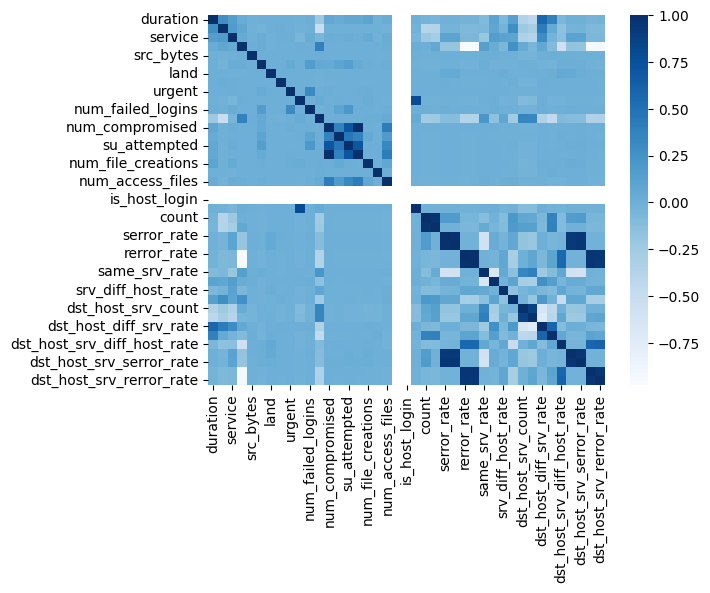

In [37]:
import seaborn as sns

sns.heatmap(X_raw.corr(), cmap='Blues')

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

target = np.where(y_raw == b'normal.', 1, -1)
print(f"Normali:  {(target == 1).sum()}")
print(f"Attacchi: {(target == -1).sum()}")

X_normal = X_raw[target == 1]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_normal)
X_all   = scaler.transform(X_raw)

print(f"Shape training (solo normali): {X_train.shape}")
print(f"Shape full dataset scalato:    {X_all.shape}")

Normali:  97278
Attacchi: 3377
Shape training (solo normali): (97278, 41)
Shape full dataset scalato:    (100655, 41)


In [51]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    max_samples=1.0,
    contamination='auto',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)
model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",1.0
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


Average Precision: 0.979
              precision    recall  f1-score   support

          -1       0.98      0.98      0.98      3377
           1       1.00      1.00      1.00     97278

    accuracy                           1.00    100655
   macro avg       0.99      0.99      0.99    100655
weighted avg       1.00      1.00      1.00    100655



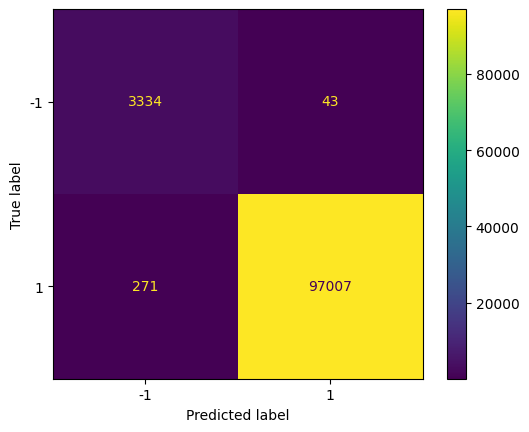

In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report, ConfusionMatrixDisplay

scores = model.score_samples(X_all)
ap = average_precision_score(target, -scores, pos_label=-1)
print(f"Average Precision: {ap:.3f}")

precisions, recalls, thresholds = precision_recall_curve(target, -scores, pos_label=-1)

best_thr = thresholds[best_idx]

preds = np.where(scores < -best_thr, -1, 1)
print(classification_report(target, preds))
ConfusionMatrixDisplay.from_predictions(target, preds)